In [10]:
# Import packages
import numpy as np
import pandas as pd
import hdbscan
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets, linear_model, metrics
from sklearn.linear_model import LinearRegression
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from functions_fcsuml import *

# Load data
df = pd.read_parquet('ready_data_2.parquet')
df2 = pd.read_parquet('ready_targets.parquet')
df.head()


,TransactionId,Lat,Lon,BuildingAge,UtilityArea,LotArea,QualityScore,CloseToBeach,EnergyPerformance,EnergyClass,...,MunicipalityMoveInFromCountyFrac,MunicipalityMoveOutToCountyFrac,MunicipalityMoveInFrac2yrChangeMean,MunicipalityMoveOutFrac2yrChangeMean,MunicipalityMoveInFromCountyFrac2yrChangeMean,MunicipalityMoveOutToCountyFrac2yrChangeMean,MunicipalityPopulationMeanDeviation,MedianRentMunicipality,MedianRentMunicipality2yrFracChangeMean,MedianRentMunicipalityMeanDeviation
0,10006194,56.742153,16.291778,48,143,480,36,0,60.0,0.125,...,0.025551,0.021314,0.001816,0.004082,0.000930,0.003437,4.373830,1155.0,0.091030,1.123790
1,10006232,57.278909,13.646019,54,120,750,32,0,114.0,0.125,...,0.010123,0.013869,-0.007777,0.006713,-0.001110,0.002518,1.843030,999.0,0.013451,0.972005
2,10006302,58.328009,15.103299,47,169,592,30,0,0.0,0.000,...,0.034871,0.028112,-0.003267,0.003278,-0.000932,0.000765,1.738860,1046.0,0.075010,1.017735
3,10006371,57.739437,14.122176,128,250,3311,30,0,88.0,0.375,...,0.013410,0.012764,-0.001062,0.001830,0.000457,0.000039,8.857676,1059.0,0.061507,1.030384
4,10006399,57.784585,16.146614,112,87,3406,28,0,101.0,0.500,...,0.006766,0.006466,-0.001024,-0.000181,0.000441,0.000045,2.279611,909.0,0.009151,0.884437


In [11]:

name_list = ['norm_data_260303.parquet', 'norm_targets_260303.parquet', 'norm_testing_targets_260303.parquet', 'norm_validation_targets.parquet',
             'norm_validation_data.parquet', 'norm_testing_data.parquet']

data_list = np.zeros(8)

for i in range(len(name_list)):
    temp = pd.read_parquet(name_list[i])
    data_list[i] = dataframe_to_numpy(temp)

norm_data, norm_targets, norm_testing_targets, norm_validation_targets, norm_validation_data, norm_testing_data = data_list

NameError: name 'dataframe_to_numpy' is not defined

# Clustering

In [ ]:

def create_clusterspan(sorted_clusters, number_of_clusters):
    clusterspan = np.zeros(number_of_clusters+2)

    for i in range(0, number_of_clusters+1):
        clusterspan[i+1] = clusterspan[i] + np.shape(sorted_clusters[np.where(sorted_clusters[:,0] == i)])[0]

    clusterspan[-1] = np.shape(sorted_clusters)[0]
    return clusterspan


def silhouette(SC, NC):
    labels = SC[:, 0]
    silhouettes = metrics.silhouette_samples(SC[:, 1:], labels)
    cluster_silhouettes = np.zeros((NC, 2))
    
    for i in range(1, NC+1):
        # print(i, NC)
        cluster_silhouettes[i-1,:] = i, np.mean(silhouettes[np.where(SC[:, 0] == i)])

    return np.mean(silhouettes), cluster_silhouettes



def optimal_cluster_size(data, max_MCS = 9000, min_MCS = 2000, step_size = 1000, max_recursion = 7, recursion = 0, first_calc=0):
    print(f'Recursion: {recursion}, data shape: {np.shape(data)}, min_MCS: {min_MCS}')
    backup = min_MCS 
    
    if first_calc !=0:
        min_MCS = first_calc
    
    max_iterations = (max_MCS-min_MCS) // step_size + 1
    Sil_mat = np.zeros((max_iterations, 3))

    cluster_mat = np.zeros((np.shape(data)[0], np.shape(data)[1]+1, max_iterations)) # For saving results

    best_silhouette = -1
    best_index = 0
    best_cluster_index = 0

    for MCS in range(min_MCS, max_MCS+1, step_size): # range(2, data_points): # MCS = minimum cluster size  range(9, 11): # 
        index = (MCS-min_MCS)//step_size
        print(data.shape)

        number_of_clusters, clustered_data = clustering(data, cluster_size=MCS, min_samples=2)
        

        if number_of_clusters < 2:
            Sil_mat[index] = MCS, 0, number_of_clusters
            print(f'{MCS} skipped because number of clusters < 2.')
            break

        clustered_data[:, 0] += 1
        

        sorted_clusters = clustered_data[clustered_data[:, 0].argsort()] # sorting the clustered data by cluster affiliation

        cluster_mat[:,:, index] = sorted_clusters

        clusterspan = create_clusterspan(sorted_clusters, number_of_clusters)
        print(clusterspan)


        average_silhouette, cluster_silhouettes = silhouette(sorted_clusters, number_of_clusters)
        print('avg:', average_silhouette, 'clu: \n', cluster_silhouettes)

        if average_silhouette > best_silhouette:
            best_silhouette, best_index, best_cluster_index = average_silhouette, index, np.argmax(cluster_silhouettes[:, 1])

        Sil_mat[index] = MCS, average_silhouette, number_of_clusters

    print(best_silhouette, best_index, best_cluster_index)

    if best_silhouette == -1:
        print(f'Stop. Cannot cluster further.')
        print('data: ', np.shape(data))
        return np.insert(data, 0, 1, axis=1)

    # print(Sil_mat)
    min_MCS = backup
    # b = a[np.where(a[1] < 3)]

    cluster_mat_best = cluster_mat[:, :, best_index]
 
    best_cluster = cluster_mat_best[np.where(cluster_mat_best[:, 0] == (best_cluster_index+1))]
    remaining_clusters = cluster_mat_best[np.where(cluster_mat_best[:, 0] != (best_cluster_index+1))]

    print(remaining_clusters.shape)
    print(np.where(remaining_clusters == 1))

    if best_cluster_index != 0:
        remaining_clusters[np.where(remaining_clusters[:, 0] == 1), 0] = best_cluster_index+1
        best_cluster[:, 0] = 1
    
    # print('bclu 1st: ', best_cluster[0,0])
    # print('remclu: ',remaining_clusters[:, 0])

    size_bc = np.shape(best_cluster)[0]
    size_rc = np.shape(remaining_clusters)[0]

    if recursion < max_recursion and size_bc > 0 and size_rc > 0:
        print(f'size_bc: {size_bc}, size_rc: {size_rc}')
        if  size_bc > min_MCS and size_bc > 3:
            # print(f'new max: {np.min([max_MCS, size_bc-2])}')
            
            new_min_bc = np.max((int(size_bc/2), 2))
            partition_1 = optimal_cluster_size(best_cluster[:, 1:], np.min([max_MCS, size_bc-2]), np.min([min_MCS, new_min_bc]), step_size=step_size, max_recursion=max_recursion, recursion=recursion+1)
        else:
            partition_1 = best_cluster
            # partition_1[:, 0] = 1

        if  size_rc > min_MCS and size_rc > 3:
            # print(f'new max: {np.min([max_MCS, size_rc-2])}')
            new_min_rc = np.max((int(size_rc/2), 2))
            partition_2 = optimal_cluster_size(remaining_clusters[:, 1:], np.min([max_MCS, size_rc-2]), np.min([min_MCS, new_min_rc]), step_size=step_size, max_recursion=max_recursion, recursion=recursion+1)
        else:
            partition_2 = remaining_clusters

        if np.min(partition_1[:,0] == 0): # All points in partition_1 should belong to a cluster
            print(f'min partition_1 = 0') # , patition_1: {partition_1}
            partition_1[:, 0] += 1
    else:
        partition_1 = best_cluster
        partition_2 = remaining_clusters



        # partition_3 = partition_2[np.where(partition_2[:, 0] == 0)]
        # partition_2 = partition_2[np.where(partition_2[:, 0] != 0)]
        # partition_2[np.where(partition_2[:, 0] < best_cluster_index+1), 0] += 1
        # partition_2 = np.vstack((partition_2, partition_3))
        # partition_1[:, 0] = 1


    # print('par2', partition_2[:, 0])

    partition_3 = partition_2[np.where(partition_2[:, 0] == 0)]
    partition_2 = partition_2[np.where(partition_2[:, 0] != 0)]

    if np.min(partition_2[:, 0]) <= np.max(partition_1[:, 0]):     # np.shape(partition_1)[0] > 0:
        partition_2[:, 0] += 1 # np.max(partition_1[:,0])-np.min(partition_2[:, 0])

    print(f'p1: {np.shape(partition_1)}, p2: {np.shape(partition_2)}, p3: {np.shape(partition_3)}')
    print(f'stack shape: {np.vstack((partition_1, partition_2, partition_3)).shape}')

    return np.vstack((partition_1, partition_2, partition_3))

# Normalizing the data
# norm_data, normalization_variables = normalize(training_data)
# print(np.shape(norm_data))

optimal_clustering = optimal_cluster_size(norm_data, 500, 50, 50)
print(optimal_clustering)

Recursion: 0, data shape: (5000, 164), min_MCS: 50
(5000, 164)
shape: (5000, 164)
[   0.   20. 4771. 5000.]
avg: 0.1374748976103212 clu: 
 [[1.         0.1316642 ]
 [2.         0.27874619]]
(5000, 164)
shape: (5000, 164)
[   0.   20. 4771. 5000.]
avg: 0.1374748976103212 clu: 
 [[1.         0.1316642 ]
 [2.         0.27874619]]
(5000, 164)
shape: (5000, 164)
[   0.   20. 4771. 5000.]
avg: 0.1374748976103212 clu: 
 [[1.         0.1316642 ]
 [2.         0.27874619]]
(5000, 164)
shape: (5000, 164)
[   0.   20. 4771. 5000.]
avg: 0.1374748976103212 clu: 
 [[1.         0.1316642 ]
 [2.         0.27874619]]
(5000, 164)
shape: (5000, 164)
[   0. 1417. 4598. 5000.]
avg: 0.0352197267796156 clu: 
 [[1.         0.06452788]
 [2.         0.24390659]]
(5000, 164)
shape: (5000, 164)
[   0. 1417. 4598. 5000.]
avg: 0.0352197267796156 clu: 
 [[1.         0.06452788]
 [2.         0.24390659]]
(5000, 164)
shape: (5000, 164)
[   0. 1417. 4598. 5000.]
avg: 0.0352197267796156 clu: 
 [[1.         0.06452788]
 [

[   0. 1288. 1517. 1615. 1999. 2104. 2224. 2602. 2871. 3101. 5000.]
avg sil: -0.02742846949003772 
 cluster silhouettes: 
 [[ 1.          0.19678541]
 [ 2.          0.21833573]
 [ 3.         -0.03946516]
 [ 4.          0.19630437]
 [ 5.         -0.02647514]
 [ 6.         -0.04392325]
 [ 7.          0.04130056]
 [ 8.          0.10831952]
 [ 9.         -0.0166014 ]] 
 argmax 1


c:\Users\Projektlotsarna\Code\Exjobb\Finding-comparable-sales-using-macine-learning\functions_fcsuml.py:91: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x1, y1, c = cmap(i), s = 1)


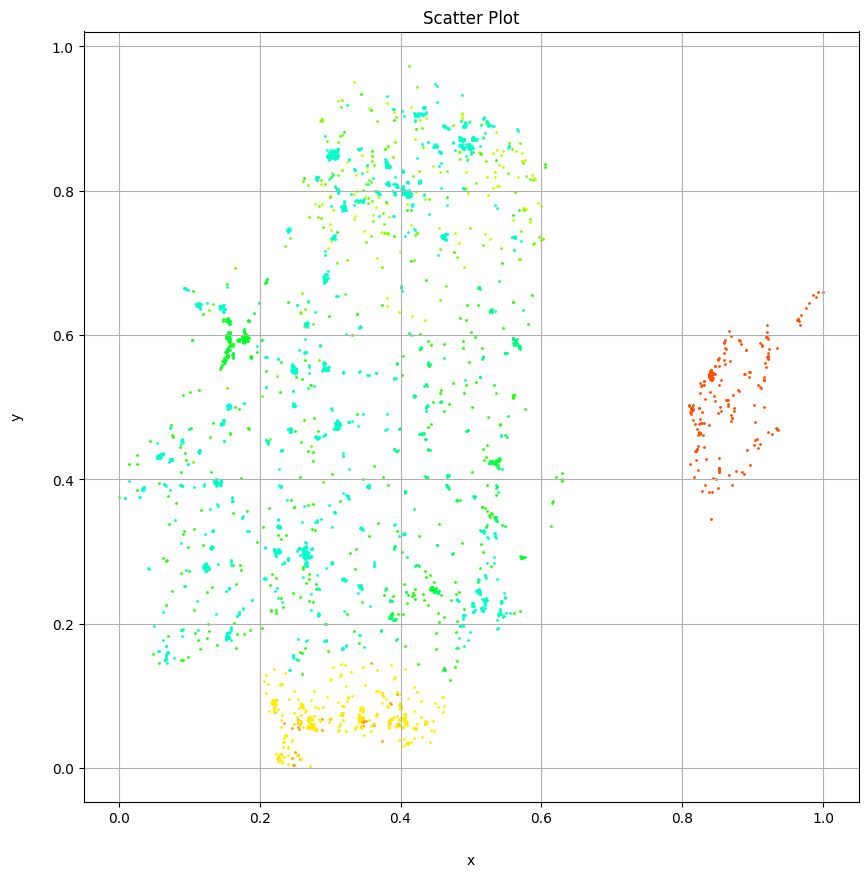

In [ ]:
sorted_clusters = optimal_clustering[optimal_clustering[:, 0].argsort()] # sorting the clustered data by cluster affiliation
number_of_clusters = int(np.max(sorted_clusters[:,0]))
clusterspan = create_clusterspan(sorted_clusters, number_of_clusters)
print(clusterspan)
average_silhouette, cluster_silhouettes = silhouette(sorted_clusters, number_of_clusters)
print('avg sil:', average_silhouette, '\n cluster silhouettes: \n', cluster_silhouettes, '\n argmax', np.argmax(cluster_silhouettes[:,1]))
show_clusters_in_latlon(norm_data, sorted_clusters, number_of_clusters, clusterspan,2, 1)